# Perfiles de clientes que dieron de baja el Paquete Premium

**Para:** guion del video ejecutivo de Miranda Wintour (Directora Comercial)
**Pregunta de negocio:** de los clientes que ya se fueron, ¿se fueron todos por lo mismo, o hay grupos con historias distintas que necesitan respuestas distintas?

Este notebook responde esa pregunta con evidencia: no predice quién se va a ir, **radiografía a los que ya se fueron** (`clase_ternaria == 'BAJA+2'`) y los compara contra clientes fieles para encontrar qué los distingue. El resultado son perfiles de cliente con nombre, comportamiento y una acción de retención concreta para cada uno.


## 1. El problema, en una frase

El banco está perdiendo clientes del Paquete Premium todos los meses. Tratar a todos los que se van como "un solo problema" lleva a una sola solución genérica — y una solución genérica rara vez convence a alguien a quedarse.

**Hipótesis de trabajo:** no todos los que se dan de baja son iguales. Hay distintos "caminos hacia la salida" — el cliente que dejó de usar la tarjeta, el que migró su sueldo a otro banco, el que nunca sintió que el paquete le sirviera, el que se fue alejando del banco de a poco, el que está ahogado en deudas. Cada camino pide una conversación distinta con el cliente.

Para encontrar esos caminos sin imponer categorías a mano, usamos un modelo como **instrumento de medición**: comparamos a cada cliente BAJA+2 contra un grupo de clientes fieles de igual tamaño, dejamos que el modelo aprenda qué variables separan a unos de otros, y agrupamos a los que se fueron según el patrón de variables que los distingue. Es el mismo trabajo que haría un analista leyendo miles de fichas de clientes en busca de similitudes — acá lo hace un algoritmo, de forma sistemática y reproducible.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sys.path.insert(0, str(Path.cwd()))
import z501_cluster_rf as clu  # este módulo fija el backend de matplotlib a Agg al importarse

import matplotlib.pyplot as plt
# el magic va después del import de z501_cluster_rf, para que gane sobre el Agg que ese módulo fija
%matplotlib inline

pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

CSV_PATH = Path("data/competencia_01.csv")
SEED = 214363


## 1.1 Panorama: ¿cuántos clientes se van, mes a mes?

Antes de entrar en los perfiles, una foto de conjunto. La `clase_ternaria` sólo está definida para los meses donde se conocen los dos meses siguientes de actividad — por eso **202103 a 202106** son los únicos cuatro meses con una cantidad de BAJA+2 ya confirmada (202107 sólo sabe BAJA+1, y 202108 no sabe nada todavía).


In [2]:
con = duckdb.connect()
todos_los_meses = sorted(con.execute(
    f"SELECT DISTINCT {clu.MES_COL} FROM read_csv('{CSV_PATH.as_posix()}', sample_size=-1)"
).df()[clu.MES_COL].tolist())
meses_con_label = todos_los_meses[:-2]  # BAJA+2 necesita conocer los 2 meses siguientes: los últimos 2 meses del dataset quedan sin etiqueta

composicion = con.execute(f'''
    SELECT {clu.MES_COL}, {clu.TARGET_COL}, COUNT(*) AS clientes
    FROM read_csv('{CSV_PATH.as_posix()}', sample_size=-1)
    WHERE {clu.TARGET_COL} IS NOT NULL
    GROUP BY {clu.MES_COL}, {clu.TARGET_COL}
    ORDER BY {clu.MES_COL}, {clu.TARGET_COL}
''').df()

tabla_mensual = composicion.pivot(index=clu.MES_COL, columns=clu.TARGET_COL, values="clientes").fillna(0).astype(int)
tabla_mensual = tabla_mensual.loc[meses_con_label, ["CONTINUA", "BAJA+1", "BAJA+2"]]
tabla_mensual["total_activos"] = tabla_mensual.sum(axis=1)
tabla_mensual["% BAJA+1"] = (100 * tabla_mensual["BAJA+1"] / tabla_mensual["total_activos"]).round(2)
tabla_mensual["% BAJA+2"] = (100 * tabla_mensual["BAJA+2"] / tabla_mensual["total_activos"]).round(2)

rentabilidad_baja2 = con.execute(f'''
    SELECT {clu.MES_COL}, SUM(mrentabilidad) AS rentabilidad_total, AVG(mrentabilidad) AS rentabilidad_prom
    FROM read_csv('{CSV_PATH.as_posix()}', sample_size=-1)
    WHERE {clu.TARGET_COL} = 'BAJA+2'
    GROUP BY {clu.MES_COL}
''').df().set_index(clu.MES_COL)
tabla_mensual["rentabilidad_total_$"] = rentabilidad_baja2["rentabilidad_total"].round(0)
tabla_mensual["rentabilidad_prom_$"] = rentabilidad_baja2["rentabilidad_prom"].round(0)
tabla_mensual


clase_ternaria,CONTINUA,BAJA+1,BAJA+2,total_activos,% BAJA+1,% BAJA+2,rentabilidad_total_$,rentabilidad_prom_$
foto_mes,,,,,,,,
202103,160921,1019,960,162900,0.6,0.6,"1,952,070.0","2,033.0"
202104,161181,964,1139,163284,0.6,0.7,"2,948,156.0","2,588.0"
202105,161755,1143,870,163768,0.7,0.5,"1,617,609.0","1,859.0"
202106,162142,874,1098,164114,0.5,0.7,"2,261,533.0","2,060.0"


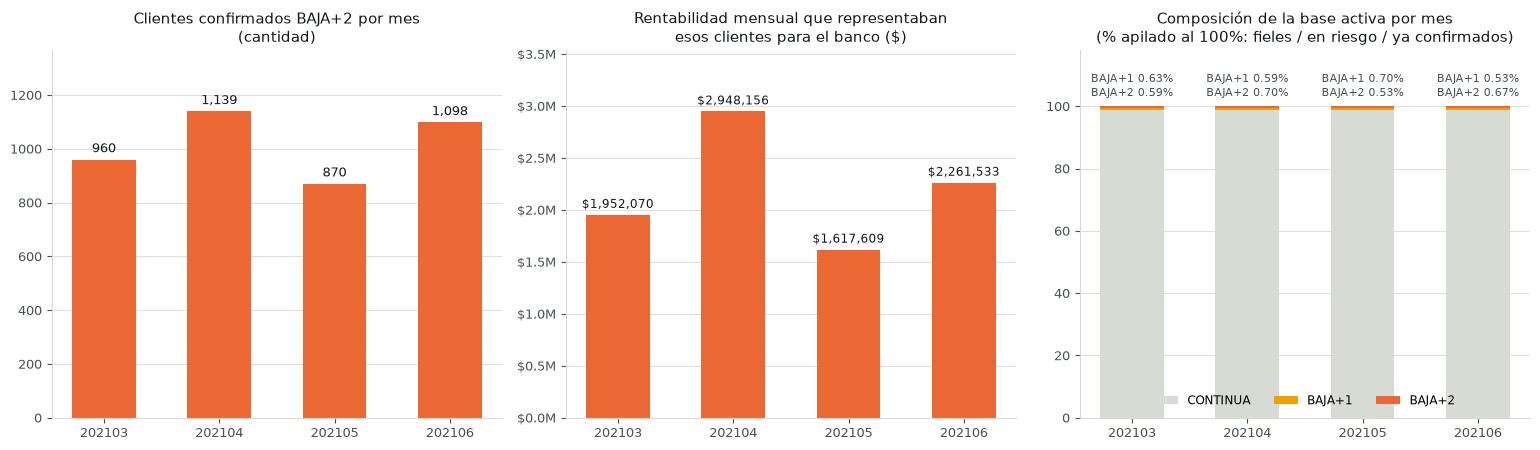

In [3]:
meses_baja = tabla_mensual.index.tolist()
x = np.arange(len(meses_baja))
COLOR_BAJA1, COLOR_BAJA2, COLOR_CONTINUA = clu.COLORES_CLUSTER[3], clu.COLORES_CLUSTER[1], clu.GRID

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

# Gráfico 1 (no apilado): cantidad absoluta de clientes BAJA+2 confirmados cada mes.
ax = axes[0]
barras = ax.bar(x, tabla_mensual["BAJA+2"], color=COLOR_BAJA2, width=0.55)
ax.bar_label(barras, fmt="{:,.0f}", padding=3, fontsize=9.5, color=clu.INK)
ax.set_xticks(x, meses_baja)
ax.set_ylim(0, tabla_mensual["BAJA+2"].max() * 1.2)
ax.set_title("Clientes confirmados BAJA+2 por mes\n(cantidad)", fontsize=11, color=clu.INK)
clu._estilo(ax)

# Gráfico 2: rentabilidad mensual que esos clientes representaban para el banco.
ax = axes[1]
barras = ax.bar(x, tabla_mensual["rentabilidad_total_$"], color=COLOR_BAJA2, width=0.55)
ax.bar_label(barras, fmt=lambda v: f"${v:,.0f}", padding=3, fontsize=8.5, color=clu.INK)
ax.set_xticks(x, meses_baja)
ax.set_ylim(0, tabla_mensual["rentabilidad_total_$"].max() * 1.2)
ax.yaxis.set_major_formatter(lambda v, pos: f"${v/1e6:.1f}M")
ax.set_title("Rentabilidad mensual que representaban\nesos clientes para el banco ($)", fontsize=11, color=clu.INK)
clu._estilo(ax)

# Gráfico 3 (100% apilado): composición de la base activa (fieles / en riesgo / ya confirmados).
ax = axes[2]
abajo = np.zeros(len(meses_baja))
for cat, color in [("CONTINUA", COLOR_CONTINUA), ("BAJA+1", COLOR_BAJA1), ("BAJA+2", COLOR_BAJA2)]:
    valores = (100 * tabla_mensual[cat] / tabla_mensual["total_activos"]).values
    ax.bar(x, valores, bottom=abajo, color=color, width=0.55, label=cat)
    abajo += valores
for xi, (b1, b2) in enumerate(zip(tabla_mensual["% BAJA+1"], tabla_mensual["% BAJA+2"])):
    ax.text(xi, 102, f"BAJA+1 {b1:.2f}%\nBAJA+2 {b2:.2f}%", ha="center", va="bottom", fontsize=7.8, color=clu.INK_2, linespacing=1.3)
ax.set_xticks(x, meses_baja)
ax.set_ylim(0, 118)
ax.set_title("Composición de la base activa por mes\n(% apilado al 100%: fieles / en riesgo / ya confirmados)", fontsize=11, color=clu.INK)
ax.legend(frameon=False, fontsize=8.5, loc="lower center", ncol=3)
clu._estilo(ax)

plt.tight_layout()
plt.show()


**Lectura:** el volumen de bajas confirmadas se mueve entre 870 (mayo) y 1.139 (abril) por mes — sin una tendencia marcada de crecimiento o caída en esta ventana de 4 meses. En términos relativos es un goteo chico (0,53%–0,70% de la base activa cada mes), pero constante: son entre 870 y 1.139 clientes del Paquete Premium perdidos **todos los meses**, mes tras mes. `BAJA+1` (los que llevan un mes sin movimiento, la señal de alerta temprana) se mantiene en un orden de magnitud similar — es la bolsa de la que sale buena parte del `BAJA+2` del mes siguiente.

Y en plata: esos clientes representaban entre **$1,6 y $2,9 millones de rentabilidad mensual** para el banco (entre $1.859 y $2.588 por cliente, según el mes) — unos **$8,8 millones** en total a lo largo de los cuatro meses. No es sólo "se van 1.000 clientes": es esa plata que deja de entrar, mes tras mes, mientras no se haga nada distinto.


## 2. Datos: todos los que se fueron, con toda su historia

Reutilizamos la lógica ya probada en [`z501_cluster_rf.py`](z501_cluster_rf.py) (carga con DuckDB, entrenamiento del Random Forest, conteo de hojas) en lugar de reescribirla. El notebook la importa como módulo y construye el relato de negocio sobre esa base.


In [4]:
import re

def cargar_diccionario(path):
    texto = Path(path).read_text(encoding="utf-8")
    significados = {}
    patron = re.compile(r"^\|\s*\d+\s*\|\s*`([^`]+)`\s*\|[^|]*\|\s*(.+?)\s*\|\s*$")
    for linea in texto.splitlines():
        m = patron.match(linea)
        if m:
            campo, significado = m.groups()
            significados[campo] = significado.strip()
    return significados

DICCIONARIO = cargar_diccionario("Diccionario.md")

# Traducciones cortas para las variables que más aparecen como definitorias de un cluster.
# El resto cae al significado largo del diccionario (truncado) como respaldo.
ETIQUETAS_NEGOCIO = {
    "mttarjeta_visa_debitos_automaticos": "Débitos automáticos en tarjeta Visa ($/mes)",
    "mtarjeta_visa_consumo": "Consumo con tarjeta Visa ($/mes)",
    "ctarjeta_visa_debitos_automaticos": "Cantidad de débitos automáticos en Visa",
    "matm": "Extracciones en cajeros automáticos ($/mes)",
    "mpayroll": "Sueldo acreditado por nómina ($/mes)",
    "mpagomiscuentas": "Pago de servicios por PagoMisCuentas ($/mes)",
    "Visa_mfinanciacion_limite": "Límite de financiación de la tarjeta Visa ($)",
    "Visa_mlimitecompra": "Límite de compra de la tarjeta Visa ($)",
    "active_quarter": "Cliente activo en el trimestre (% con movimientos voluntarios)",
    "cdescubierto_preacordado": "Tiene acuerdo de descubierto (%)",
    "internet": "Usa Homebanking / app móvil (%)",
    "cprestamos_personales": "Préstamos personales vigentes (cantidad)",
    "mprestamos_personales": "Deuda total en préstamos personales ($)",
}

def etiqueta(attr):
    if attr in ETIQUETAS_NEGOCIO:
        return ETIQUETAS_NEGOCIO[attr]
    return DICCIONARIO.get(attr, attr)[:70]

def moneda(v):
    return f"$ {v:,.0f}".replace(",", ".")


In [5]:
df = clu.cargar_muestra(CSV_PATH, SEED)
feats = clu.columnas_features(df)
por_grupo = df.groupby(clu.GRUPO_COL)[clu.ID_COL].agg(ids="nunique", filas="size")

print(f"Clientes que se dieron de baja (BAJA+2), con toda su historia: {por_grupo.loc[1, 'ids']:,}")
print(f"Clientes fieles usados como contraste (mismo tamaño de muestra): {por_grupo.loc[0, 'ids']:,}")
print(f"Filas cliente-mes analizadas en total: {len(df):,}")
print(f"Variables de comportamiento disponibles: {len(feats)}")


Clientes que se dieron de baja (BAJA+2), con toda su historia: 4,067
Clientes fieles usados como contraste (mismo tamaño de muestra): 4,067
Filas cliente-mes analizadas en total: 38,713
Variables de comportamiento disponibles: 152


La muestra toma **todos** los clientes BAJA+2 (no un recorte), con todos los meses en que fueron clientes, y los compara contra un número igual de clientes fieles. Así el modelo aprende a distinguir comportamiento de "cliente que se queda" vs. "cliente que se va" sin sesgos de tamaño de muestra.


In [6]:
X = df[feats].to_numpy(dtype=np.float32)
y = df[clu.GRUPO_COL].to_numpy()
ids = df[clu.ID_COL].to_numpy()

rf = clu.entrenar_rf(X, y, n_trees=300, min_samples_leaf=50, seed=SEED)

P = clu.normalizar(clu.contar_hojas_por_id(rf, X, ids, feats))
ids_churn = pd.Index(df.loc[df[clu.GRUPO_COL] == 1, clu.ID_COL].unique())
P_churn = P.loc[ids_churn]

print(f"El modelo distingue BAJA+2 de fieles con {rf.oob_score_:.1%} de acierto (nota técnica, no es el foco del análisis).")
print(f"Perfil de comportamiento construido para {P_churn.shape[0]:,} clientes BAJA+2, a partir de {P_churn.shape[1]} variables relevantes.")


El modelo distingue BAJA+2 de fieles con 84.5% de acierto (nota técnica, no es el foco del análisis).
Perfil de comportamiento construido para 4,067 clientes BAJA+2, a partir de 129 variables relevantes.


## 3. ¿Cuántos perfiles distintos tiene sentido mostrarle a Miranda?

Antes de nombrar perfiles, hay que decidir cuántos mostrar. Muy pocos (2-3) esconden historias distintas dentro de un mismo grupo. Demasiados (7+) son imposibles de explicar en un video de 5 minutos. Probamos k = 3, 4, 5 y 6 y miramos tres cosas: qué tan compactos y separados quedan los grupos (estadística), qué tan grande es el grupo más chico (¿vale la pena una campaña para 20 clientes?) y, sobre todo, **si cada grupo cuenta una historia de negocio distinta o si dos grupos distintos esconden el mismo problema**.


In [7]:
resultados_k = {}
labels_por_k = {}
caracterizacion_por_k = {}

for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(P_churn.values)
    sil = silhouette_score(P_churn.values, km.labels_)
    labels = clu.clusterizar(P_churn, k, SEED)
    attrs_def = clu.caracterizar_clusters(P_churn, labels, top_n=3, share_min=0.5 / P_churn.shape[1])
    tam = labels.value_counts().sort_index()

    labels_por_k[k] = labels
    caracterizacion_por_k[k] = attrs_def
    resultados_k[k] = {
        "inercia": round(km.inertia_, 1),
        "silhouette": round(sil, 4),
        "grupo_mas_chico_%": round(100 * tam.min() / len(labels), 1),
        "cantidad_de_grupos": k,
    }

tabla_k = pd.DataFrame(resultados_k).T.set_index("cantidad_de_grupos")
tabla_k


,inercia,silhouette,grupo_mas_chico_%
cantidad_de_grupos,,,
3.0,22.6,0.2,18.6
4.0,21.2,0.1,18.4
5.0,20.1,0.1,5.5
6.0,19.3,0.1,5.3


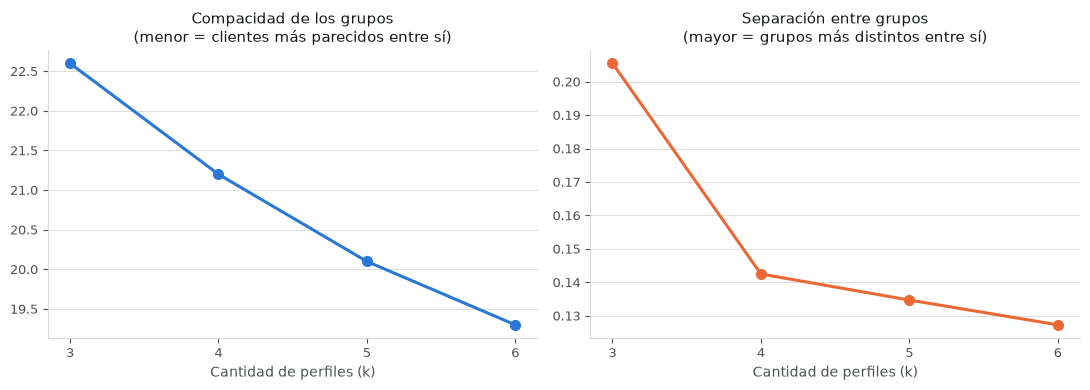

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(tabla_k.index, tabla_k["inercia"], color=clu.COLORES_CLUSTER[0], linewidth=2.2, marker="o", markersize=7)
ax.set_title("Compacidad de los grupos\n(menor = clientes más parecidos entre sí)", fontsize=10.5, color=clu.INK)
clu._estilo(ax)

ax = axes[1]
ax.plot(tabla_k.index, tabla_k["silhouette"], color=clu.COLORES_CLUSTER[1], linewidth=2.2, marker="o", markersize=7)
ax.set_title("Separación entre grupos\n(mayor = grupos más distintos entre sí)", fontsize=10.5, color=clu.INK)
clu._estilo(ax)

for ax in axes:
    ax.set_xticks(tabla_k.index)
    ax.set_xlabel("Cantidad de perfiles (k)", color=clu.INK_2)

plt.tight_layout()
plt.show()


**Lo que dicen los números, y por qué no alcanza con mirarlos solos:**

La separación estadística (silhouette) es más alta cuanto menos grupos hay — eso es casi siempre así con este tipo de modelo y no es un argumento de negocio por sí solo. Lo que importa es si, al bajar la cantidad de grupos, se pierden historias distintas. Mirando las variables que definen a cada grupo con k=3 y k=4:


In [9]:
for k in [3, 4]:
    print(f"--- k = {k} ---")
    for c, g in caracterizacion_por_k[k].groupby(clu.CLUSTER_COL):
        n = (labels_por_k[k] == c).sum()
        variables = ", ".join(f"{etiqueta(r.atributo)} (lift {r.lift:.1f})" for r in g.itertuples())
        print(f"  cluster_{c} (n={n:,}): {variables}")
    print()


--- k = 3 ---
  cluster_1 (n=2,294): Cantidad de débitos automáticos en Visa (lift 1.7), Débitos automáticos en tarjeta Visa ($/mes) (lift 1.7), Monto total expresado en pesos, (lift 1.7)
  cluster_2 (n=1,017): Límite de financiación de la tarjeta Visa ($) (lift 1.7), Límite de compra de la tarjeta Visa ($) (lift 1.7), Dias desde el alta de la cuenta de la tarjeta de crédito, contados a l (lift 1.6)
  cluster_3 (n=756): Tiene acuerdo de descubierto (%) (lift 4.2), Usa Homebanking / app móvil (%) (lift 4.0), Préstamos personales vigentes (cantidad) (lift 3.8)

--- k = 4 ---
  cluster_1 (n=1,284): Débitos automáticos en tarjeta Visa ($/mes) (lift 2.0), Consumo con tarjeta Visa ($/mes) (lift 1.9), Cantidad de débitos automáticos en Visa (lift 1.9)
  cluster_2 (n=1,097): Extracciones en cajeros automáticos ($/mes) (lift 3.0), Sueldo acreditado por nómina ($/mes) (lift 3.0), Pago de servicios por PagoMisCuentas ($/mes) (lift 3.0)
  cluster_3 (n=936): Límite de financiación de la tarjeta Vis

Con **k=3** y con **k=4**, el último grupo mezcla en una sola bolsa a dos tipos de cliente muy distintos: el que tiene un acuerdo de descubierto y se está alejando del banco de a poco, y el que está fuertemente endeudado con préstamos personales. Son dos problemas — y dos conversaciones — completamente distintas: a uno hay que reconectarlo, al otro hay que ofrecerle una reestructuración de deuda antes de perderlo. Juntarlos en un solo "perfil" para el video llevaría a aplicar la acción equivocada a la mitad de ese grupo.

Con **k=5**, esos dos casos se separan limpiamente en dos grupos propios, y los cinco grupos quedan todos por encima del 5% de los clientes BAJA+2 — ninguno es un micro-segmento sin peso comercial. Con **k=6** se gana una subdivisión adicional dentro del grupo de "nómina" (separa a quien paga servicios con tarjeta Mastercard de quien solo extrae efectivo), pero es una distinción de producto más fina que no cambia la acción de retención ni agrega una historia nueva — y un sexto perfil empieza a ser difícil de sostener en un video de 5 minutos.

**Decisión: k = 5.** Es el punto donde cada grupo cuenta una historia distinta y accionable, todos tienen peso comercial real, y coincide con el análisis de referencia (`clusters_tendencias_base.pdf`) — así el equipo no tiene que aprender un esquema nuevo.


In [10]:
K_FINAL = 5
labels = labels_por_k[K_FINAL]
attrs_def = clu.caracterizar_clusters(P_churn, labels, top_n=3, share_min=0.5 / P_churn.shape[1])
lift_all = P_churn.groupby(labels).mean() / P_churn.mean(axis=0)
tam = labels.value_counts().sort_index()

df_churn = df[df[clu.GRUPO_COL] == 1].merge(labels, left_on=clu.ID_COL, right_index=True)
meses = sorted(df[clu.MES_COL].unique().tolist())[:-1]
mes_excluido = sorted(df[clu.MES_COL].unique().tolist())[-1]
atributos_clave = attrs_def["atributo"].unique().tolist()
tend = clu.tendencias_por_cluster(df_churn, atributos_clave, meses, banda="ic95")

print(f"Meses analizados: {meses[0]}-{meses[-1]} ({mes_excluido} se excluye: ya no hay BAJA+2 con historia ahí)")
for c in sorted(tam.index):
    print(f"cluster_{c}: {tam[c]:,} clientes ({100 * tam[c] / tam.sum():.1f}% del total BAJA+2)")


Meses analizados: 202103-202107 (202108 se excluye: ya no hay BAJA+2 con historia ahí)
cluster_1: 1,281 clientes (31.5% del total BAJA+2)
cluster_2: 1,089 clientes (26.8% del total BAJA+2)
cluster_3: 915 clientes (22.5% del total BAJA+2)
cluster_4: 559 clientes (13.7% del total BAJA+2)
cluster_5: 223 clientes (5.5% del total BAJA+2)


### 3.1 ¿Los cinco perfiles están emparentados entre sí?

Antes de pasar a los perfiles: ¿son cinco grupos igual de distintos entre sí, o hay pares más parecidos que otros? Para verlo, cruzamos a qué grupo cae cada cliente con k=5 contra dónde cae ese mismo cliente si le pedimos sólo k=3 o k=2 grupos (mismos datos, misma semilla). Si dos clusters de k=5 van casi enteros al mismo grupo cuando hay menos lugares disponibles, es porque el propio modelo los considera "parecidos" — la única razón por la que se separan a k=5 es que hay más lugar para matizar.


In [11]:
labels_2 = clu.clusterizar(P_churn, 2, SEED)

print("k=5 (filas) vs. k=3 (columnas) — cuántos clientes de cada cluster de k=5 caen en cada grupo de k=3:")
print(pd.crosstab(labels, labels_por_k[3]))
print()
print("k=5 (filas) vs. k=2 (columnas):")
print(pd.crosstab(labels, labels_2))


k=5 (filas) vs. k=3 (columnas) — cuántos clientes de cada cluster de k=5 caen en cada grupo de k=3:
cluster     1    2    3
cluster                
1        1224   57    0
2        1058   29    2
3           1  913    1
4           0   11  548
5          11    7  205

k=5 (filas) vs. k=2 (columnas):
cluster     1    2
cluster           
1        1281    0
2        1088    1
3         897   18
4          11  548
5          17  206


**Lectura:** cluster_1 y cluster_2 son el par más parecido de los cinco — el 96-97% de cada uno cae en el mismo grupo apenas bajamos a k=3, y lo mismo pasa a k=2. No es casualidad que se vean "pegados" en el gráfico de tarjeta Visa de la sección anterior: para el modelo son, en el fondo, la misma familia de cliente (uno que tiene una relación activa y de varios productos con el banco), que recién se separa en dos sabores — tarjeta vs. nómina/cajero — cuando le damos más lugar para matizar (k=5).

La estructura completa, de más grueso a más fino:
- **k=2:** clientes con una relación "normal" de banco (clusters 1+2+3) vs. clientes con relación chica o en problemas (clusters 4+5).
- **k=3:** de los "normales", se separan los que están activos de verdad (1+2) de los que tienen todos los productos pero no los usan (3).
- **k=5:** los activos se dividen por canal — tarjeta (1) vs. nómina/cajero (2) — y los chicos/en problemas se dividen por intensidad — genérico (4) vs. sobre-endeudado (5).

Esto no cambia la decisión de usar k=5 (cada separación sigue siendo una historia y una acción distinta), pero sí explica por qué algunas comparaciones entre clusters parecen más sutiles que otras: cluster_1 vs. cluster_2 es una diferencia de matiz dentro de la misma familia; cluster_1 vs. cluster_5, en cambio, son dos familias distintas desde el primer corte.


## 4. Los cinco perfiles: quiénes son y por qué se fueron

Para cada perfil mostramos: las variables que más lo distinguen del resto (traducidas a lenguaje de negocio), cómo evolucionó esa variable mes a mes antes de la baja, y la lectura comercial de ese patrón.


In [12]:
def grafico_tendencia(attr, cluster_foco, titulo, subtitulo=""):
    fig, ax = plt.subplots(figsize=(9, 4.3))
    clusters_todos = sorted(tend.index.get_level_values(clu.CLUSTER_COL).unique())
    x = np.arange(len(meses))

    for c in clusters_todos:
        s = tend.xs(c, level=clu.CLUSTER_COL)
        centro = s["centro"][attr].reindex(meses).values
        color = clu.COLORES_CLUSTER[c - 1]
        if c == cluster_foco:
            lo = s["lo"][attr].reindex(meses).values
            hi = s["hi"][attr].reindex(meses).values
            ax.fill_between(x, lo, hi, color=color, alpha=0.15, linewidth=0)
            ax.plot(x, centro, color=color, linewidth=2.6, marker="o", markersize=7,
                     label=f"cluster_{c}  (este perfil)", zorder=3)
        else:
            ax.plot(x, centro, color=color, linewidth=1.2, alpha=0.32, marker="o", markersize=3,
                     label=f"cluster_{c}", zorder=1)

    ax.set_xticks(x, meses)
    ax.set_xlim(-0.3, len(meses) - 0.7)
    clu._estilo(ax)
    ax.legend(frameon=False, fontsize=8, loc="best")
    ax.set_ylabel(etiqueta(attr), color=clu.INK_2, fontsize=9.5)

    n_ini, n_fin = tend.xs(cluster_foco, level=clu.CLUSTER_COL)["n"][attr].reindex(meses).iloc[[0, -1]]
    fig.text(0.07, 0.98, titulo, fontsize=14, color=clu.INK, weight="bold", va="top")
    fig.text(0.07, 0.93, subtitulo or f"El grupo pasa de {int(n_ini):,} a {int(n_fin):,} clientes entre {meses[0]} y {meses[-1]}.",
              fontsize=9.5, color=clu.INK_2, va="top")
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()


### Cluster 1 — "El Tarjetahabiente Visa Desencantado" (31.5% · ~1.281 clientes)

Es, por lejos, el grupo con más débitos automáticos en su tarjeta Visa: suscripciones y servicios que se cobran solos todos los meses. También muestra un consumo mensual elevado con la tarjeta. Son, en el papel, el tipo de cliente que cualquier banco quiere retener: tienen el producto incorporado a su rutina.

**Por qué se van:** esos débitos automáticos vienen en caída antes de la baja y el grupo se achica mes a mes. No son clientes desconectados del banco — al contrario, son usuarios con la tarjeta integrada a su día a día que empiezan a soltarla. Es una señal costosa: se está perdiendo a clientes de alto valor transaccional, probablemente porque no sienten un beneficio diferencial frente a la competencia (cashback, millas, descuentos) que justifique seguir concentrando ahí sus pagos recurrentes.


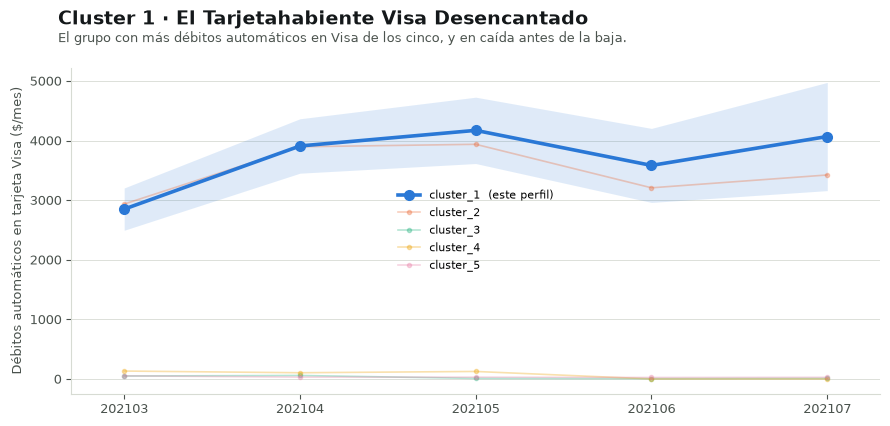

In [13]:
grafico_tendencia(
    "mttarjeta_visa_debitos_automaticos", cluster_foco=1,
    titulo="Cluster 1 · El Tarjetahabiente Visa Desencantado",
    subtitulo="El grupo con más débitos automáticos en Visa de los cinco, y en caída antes de la baja.",
)


**Aclaración:** en el gráfico de arriba, cluster_1 (azul) y cluster_2 (naranja) se ven casi pegados — en marzo incluso cluster_2 está apenas por encima. No es un error del gráfico: cluster_2 *también* usa la tarjeta Visa por encima del promedio, sólo que no es lo que más lo distingue. La diferencia real entre los dos aparece en otro lado: cuánto sacan de cajero automático y cuánto les depositan de sueldo (nómina). Ahí sí se separan por completo — son casi espejos uno del otro.


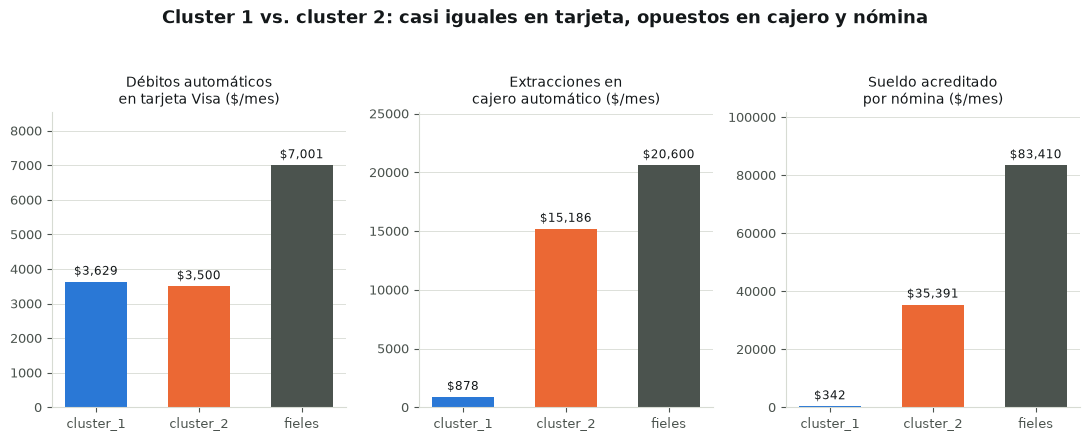

In [14]:
variables_contraste = [
    ("mttarjeta_visa_debitos_automaticos", "Débitos automáticos\nen tarjeta Visa ($/mes)"),
    ("matm", "Extracciones en\ncajero automático ($/mes)"),
    ("mpayroll", "Sueldo acreditado\npor nómina ($/mes)"),
]
promedios = df_churn.groupby(clu.CLUSTER_COL)[[a for a, _ in variables_contraste]].mean()
fieles_prom = df.loc[df[clu.GRUPO_COL] == 0, [a for a, _ in variables_contraste]].mean()

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2))
for ax, (attr, titulo) in zip(axes, variables_contraste):
    valores = [promedios.loc[1, attr], promedios.loc[2, attr], fieles_prom[attr]]
    barras = ax.bar(["cluster_1", "cluster_2", "fieles"], valores,
                     color=[clu.COLORES_CLUSTER[0], clu.COLORES_CLUSTER[1], clu.INK_2], width=0.6)
    ax.bar_label(barras, fmt=lambda v: f"${v:,.0f}", padding=3, fontsize=8.5, color=clu.INK)
    ax.set_ylim(0, max(valores) * 1.22)
    ax.set_title(titulo, fontsize=9.8, color=clu.INK)
    ax.tick_params(axis="x", labelsize=8)
    clu._estilo(ax)

fig.suptitle("Cluster 1 vs. cluster 2: casi iguales en tarjeta, opuestos en cajero y nómina", fontsize=13, color=clu.INK, weight="bold", y=1.04)
plt.tight_layout()
plt.show()


**Lectura:** en cajero y nómina, cluster_1 está casi en cero (no es su perfil) y cluster_2 domina — ahí sí son espejos. En tarjeta Visa, ambos están igual de lejos de un cliente fiel: cluster_1 usa la mitad que fieles, cluster_2 bastante menos. El patrón se repite: cada cluster tiene **un** canal donde se nota (y eso alcanza para distinguirlos entre sí), pero ninguno llega al nivel de actividad de un cliente que se queda.


### Cluster 2 — "El Sueldo que se Va" (26.8% · ~1.089 clientes)

Es el cliente "de nómina": su sueldo entra por acreditación de haberes, retira efectivo en cajeros y paga sus servicios por PagoMisCuentas — muy por encima de cualquier otro grupo que también se fue (ver el gráfico de abajo). Tiene menos productos de inversión y de crédito que un cliente fiel típico: usa más el banco como canal de paso para el día a día que como un lugar donde hace crecer su plata o pide préstamos.

**Por qué se van:** el monto de sueldo acreditado cae fuerte apenas empieza la ventana observada (de ~$44.500 a ~$31.700) y las extracciones en cajero y pagos de servicios acompañan la caída. El patrón es compatible con una **migración de nómina**: el empleador cambió de banco pagador, o el cliente cambió de trabajo, y el vínculo con el banco se licúa antes de que el cliente cierre formalmente la cuenta.


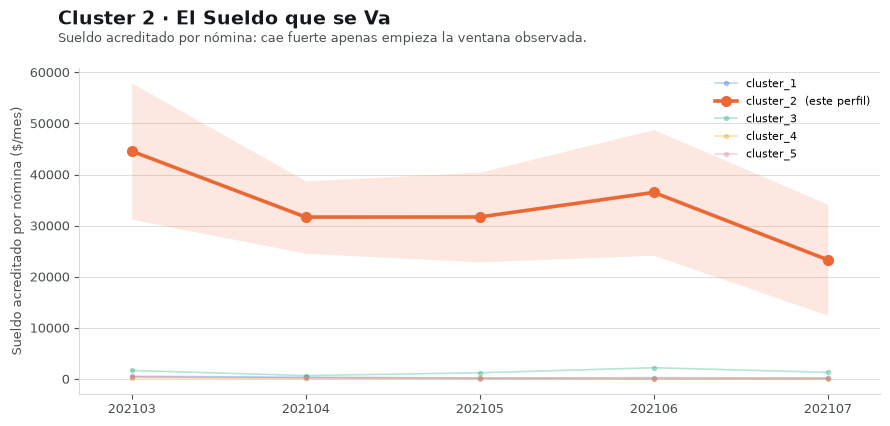

In [15]:
grafico_tendencia(
    "mpayroll", cluster_foco=2,
    titulo="Cluster 2 · El Sueldo que se Va",
    subtitulo="Sueldo acreditado por nómina: cae fuerte apenas empieza la ventana observada.",
)


**¿Cuánto más que el resto, y cuánto más que un cliente fiel?** La afirmación de arriba tiene dos comparaciones distintas adentro, y vale la pena separarlas:


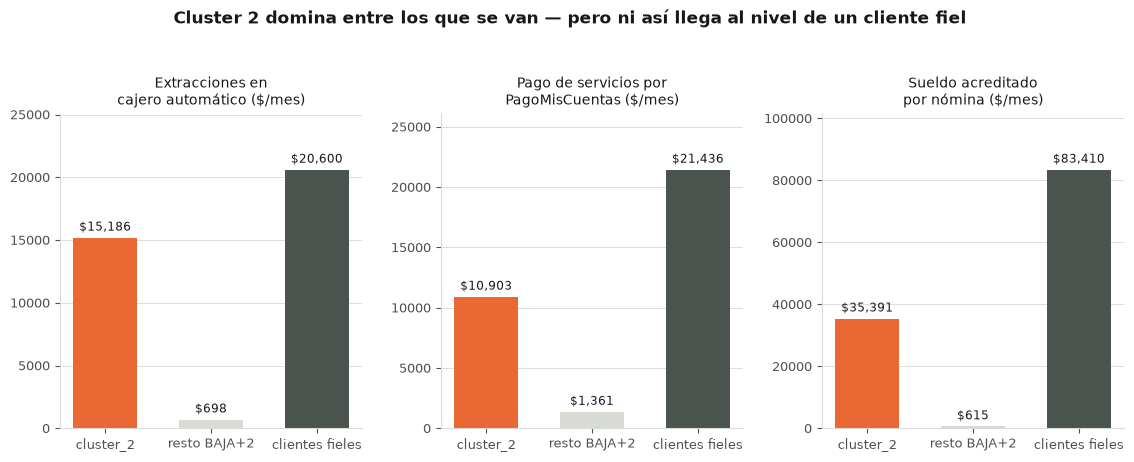

In [16]:
variables_canal = [
    ("matm", "Extracciones en\ncajero automático ($/mes)"),
    ("mpagomiscuentas", "Pago de servicios por\nPagoMisCuentas ($/mes)"),
    ("mpayroll", "Sueldo acreditado\npor nómina ($/mes)"),
]
grupos = {
    "cluster_2": df_churn.loc[df_churn[clu.CLUSTER_COL] == 2],
    "resto BAJA+2": df_churn.loc[df_churn[clu.CLUSTER_COL] != 2],
    "clientes fieles": df[df[clu.GRUPO_COL] == 0],
}
colores_grupo = {"cluster_2": clu.COLORES_CLUSTER[1], "resto BAJA+2": clu.GRID, "clientes fieles": clu.INK_2}

fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.4))
for ax, (attr, titulo) in zip(axes, variables_canal):
    valores = [grupos[g][attr].mean() for g in grupos]
    barras = ax.bar(list(grupos.keys()), valores, color=[colores_grupo[g] for g in grupos], width=0.6)
    ax.bar_label(barras, fmt=lambda v: f"${v:,.0f}", padding=3, fontsize=8.5, color=clu.INK)
    ax.set_ylim(0, max(valores) * 1.22)
    ax.set_title(titulo, fontsize=9.8, color=clu.INK)
    ax.tick_params(axis="x", labelsize=8)
    clu._estilo(ax)

fig.suptitle("Cluster 2 domina entre los que se van — pero ni así llega al nivel de un cliente fiel", fontsize=12.5, color=clu.INK, weight="bold", y=1.04)
plt.tight_layout()
plt.show()


**Lectura:** frente a los otros 4 grupos que también se fueron, cluster_2 no tiene competencia — usa entre 8 y 57 veces más estos tres canales. Pero comparado con un cliente fiel típico, está entre 26% y 58% por debajo en los tres. No es que se va el mejor cliente de nómina del banco: es que, **dentro de los que se van**, el canal nómina/cajero era lo único relativamente fuerte que tenían — y aun así, ya era una relación más chica que la de un cliente fiel promedio. Eso es consistente con la hipótesis de migración: probablemente no era su cuenta sueldo principal, o ya venía perdiendo peso, lo que hace más fácil terminar de soltarla del todo.


### Cluster 3 — "El Cliente Completo que Nunca Se Activó" (22.5% · ~915 clientes)

A diferencia de los otros cuatro perfiles, acá no hay un producto o canal que sobresalga. Tiene la tarjeta Visa y el acuerdo de descubierto casi al mismo nivel que un cliente fiel — no le falta ningún producto básico del paquete. Lo que lo distingue no es algo que tiene de más, es algo que le falta: es el grupo con la **actividad más baja de los cinco** (`active_quarter`), por debajo incluso de cluster_4, y mantiene el saldo de sus cuentas prácticamente en cero.


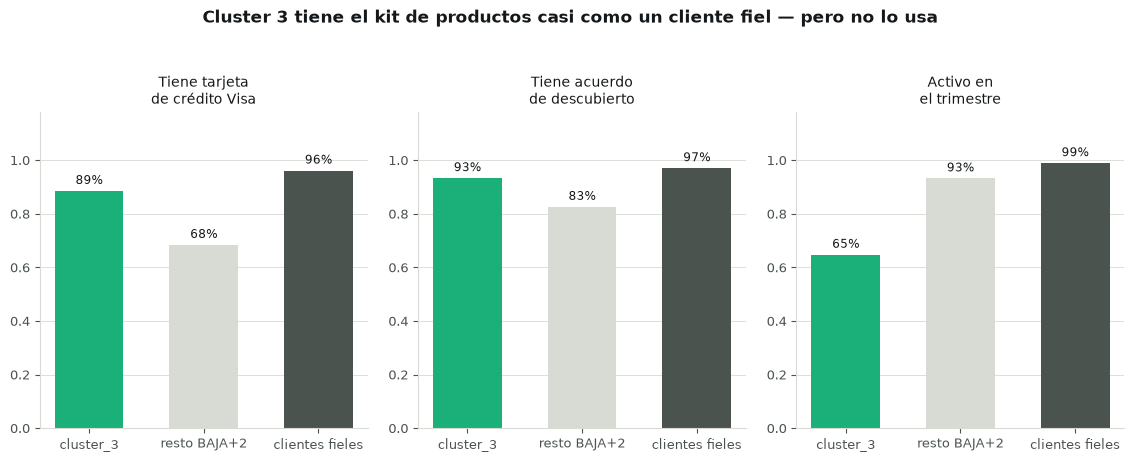

In [17]:
variables_kit = [
    ("ctarjeta_visa", "Tiene tarjeta\nde crédito Visa"),
    ("cdescubierto_preacordado", "Tiene acuerdo\nde descubierto"),
    ("active_quarter", "Activo en\nel trimestre"),
]
grupos3 = {
    "cluster_3": df_churn.loc[df_churn[clu.CLUSTER_COL] == 3],
    "resto BAJA+2": df_churn.loc[df_churn[clu.CLUSTER_COL] != 3],
    "clientes fieles": df[df[clu.GRUPO_COL] == 0],
}
colores_grupo3 = {"cluster_3": clu.COLORES_CLUSTER[2], "resto BAJA+2": clu.GRID, "clientes fieles": clu.INK_2}

fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.4))
for ax, (attr, titulo) in zip(axes, variables_kit):
    valores = [grupos3[g][attr].mean() for g in grupos3]
    barras = ax.bar(list(grupos3.keys()), valores, color=[colores_grupo3[g] for g in grupos3], width=0.6)
    ax.bar_label(barras, fmt=lambda v: f"{v:.0%}", padding=3, fontsize=8.5, color=clu.INK)
    ax.set_ylim(0, 1.18)
    ax.set_title(titulo, fontsize=9.8, color=clu.INK)
    ax.tick_params(axis="x", labelsize=8)
    clu._estilo(ax)

fig.suptitle("Cluster 3 tiene el kit de productos casi como un cliente fiel — pero no lo usa", fontsize=12.5, color=clu.INK, weight="bold", y=1.04)
plt.tight_layout()
plt.show()


**Por qué se van:** no hay una caída dramática antes de la baja porque no hay mucho que caer — la actividad ya es baja desde el primer mes que los vemos y se mantiene así los cinco meses. Es el cliente que el banco "tiene" en el papel, con el kit completo de productos, pero que nunca construyó una relación de uso real. El riesgo acá no es un shock puntual ni una caída que se pueda detectar a tiempo — es un vínculo que nunca despegó, y por eso es el más difícil de "salvar" con una alerta temprana: no hay nada que se mueva antes de que se vayan.


### Cluster 4 — "El Cliente Chico en Rojo" (13.7% · ~559 clientes)

Usa canales digitales (Homebanking / app) bastante más que los clusters 1, 2 y 3 — aunque menos que el cluster 5. Pero lo que más lo distingue es lo que no tiene: es el grupo con **menos productos de los cinco** y prácticamente sin tarjeta de crédito Visa, y su actividad general (`active_quarter`) es de las más bajas.


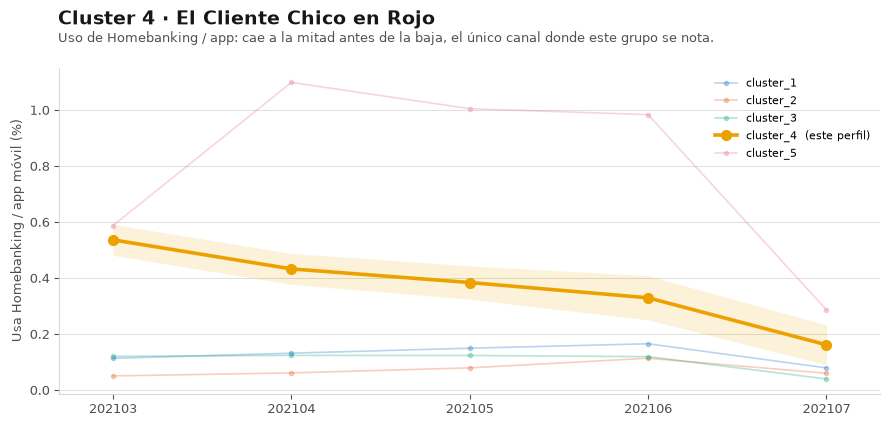

In [18]:
grafico_tendencia(
    "internet", cluster_foco=4,
    titulo="Cluster 4 · El Cliente Chico en Rojo",
    subtitulo="Uso de Homebanking / app: cae a la mitad antes de la baja, el único canal donde este grupo se nota.",
)


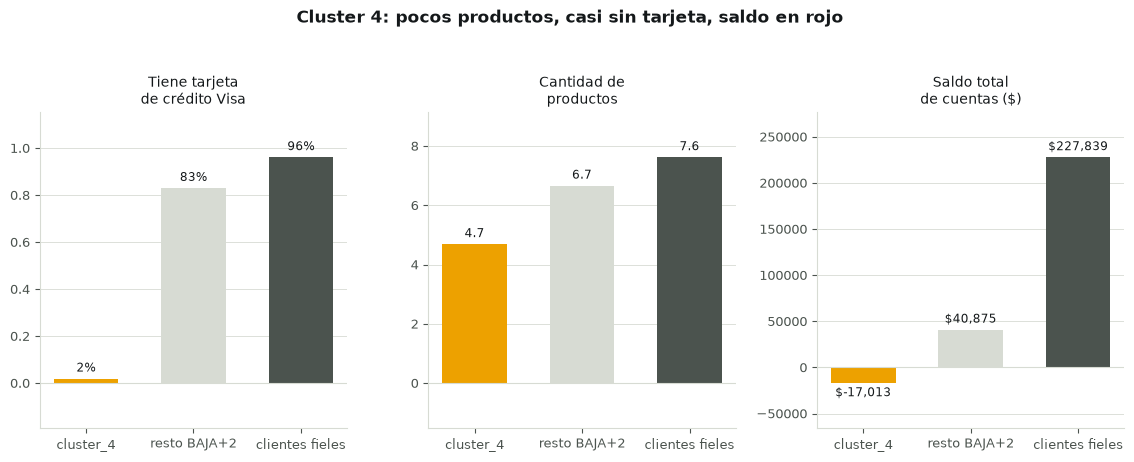

In [19]:
variables_chico = [
    ("ctarjeta_visa", "Tiene tarjeta\nde crédito Visa"),
    ("cproductos", "Cantidad de\nproductos"),
    ("mcuentas_saldo", "Saldo total\nde cuentas ($)"),
]
grupos4 = {
    "cluster_4": df_churn.loc[df_churn[clu.CLUSTER_COL] == 4],
    "resto BAJA+2": df_churn.loc[df_churn[clu.CLUSTER_COL] != 4],
    "clientes fieles": df[df[clu.GRUPO_COL] == 0],
}
colores_grupo4 = {"cluster_4": clu.COLORES_CLUSTER[3], "resto BAJA+2": clu.GRID, "clientes fieles": clu.INK_2}
formatos4 = {"ctarjeta_visa": lambda v: f"{v:.0%}", "cproductos": lambda v: f"{v:.1f}", "mcuentas_saldo": lambda v: f"${v:,.0f}"}

fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.4))
for ax, (attr, titulo) in zip(axes, variables_chico):
    valores = [grupos4[g][attr].mean() for g in grupos4]
    barras = ax.bar(list(grupos4.keys()), valores, color=[colores_grupo4[g] for g in grupos4], width=0.6)
    ax.bar_label(barras, fmt=formatos4[attr], padding=3, fontsize=8.5, color=clu.INK)
    ymin, ymax = min(valores + [0]), max(valores + [0])
    pad = (ymax - ymin) * 0.2 or 1
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color=clu.GRID, linewidth=0.8)
    ax.set_title(titulo, fontsize=9.8, color=clu.INK)
    ax.tick_params(axis="x", labelsize=8)
    clu._estilo(ax)

fig.suptitle("Cluster 4: pocos productos, casi sin tarjeta, saldo en rojo", fontsize=12.5, color=clu.INK, weight="bold", y=1.04)
plt.tight_layout()
plt.show()


**Por qué se van:** ya venían con una relación chica — pocos productos, sin tarjeta — y la van soltando del todo. El uso de la app, que era el único canal donde este grupo se destacaba, cae de 53% a 16% entre marzo y julio, y el saldo de sus cuentas está en rojo en promedio. A diferencia del cluster_3 ("tiene todo y no lo usa"), acá es al revés: nunca tuvo mucho para empezar, y lo poco que tenía se va apagando antes de la baja formal.


### Cluster 5 — "El Cliente Sobre-endeudado" (5.5% · ~223 clientes)

El grupo más chico, y el más extremo: tiene muchas más veces la cantidad de préstamos personales vigentes que el resto, y una deuda total en préstamos personales de alrededor de $250.000 — muy por encima de cualquier otro grupo, y también muy por encima de un cliente fiel (ver gráfico abajo).

**Por qué se van:** no es un cliente desconectado, es un cliente **sobrecargado de deuda**. La deuda se mantiene estable y alta hasta que, en el último mes observado, cae junto con el tamaño del grupo — compatible con un proceso de cancelación de deuda (propia o por mora) que termina en el cierre de la relación completa con el banco. Es el grupo más chico, pero el de mayor exposición económica individual y el de mayor riesgo: la conversación acá no es comercial, es de gestión de riesgo y renegociación de deuda.


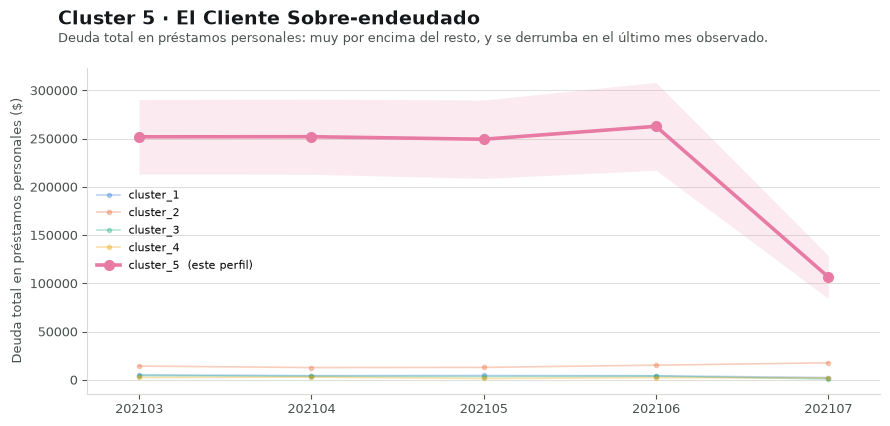

In [20]:
grafico_tendencia(
    "mprestamos_personales", cluster_foco=5,
    titulo="Cluster 5 · El Cliente Sobre-endeudado",
    subtitulo="Deuda total en préstamos personales: muy por encima del resto, y se derrumba en el último mes observado.",
)


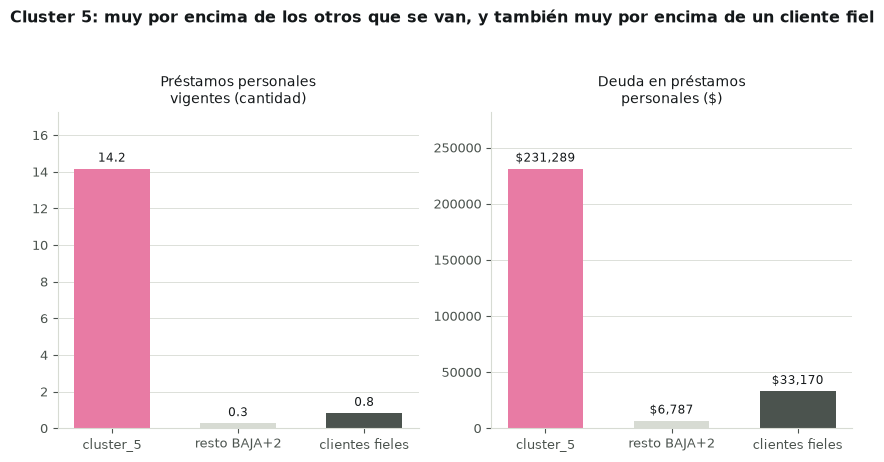

In [21]:
variables_deuda = [
    ("cprestamos_personales", "Préstamos personales\nvigentes (cantidad)"),
    ("mprestamos_personales", "Deuda en préstamos\npersonales ($)"),
]
grupos5 = {
    "cluster_5": df_churn.loc[df_churn[clu.CLUSTER_COL] == 5],
    "resto BAJA+2": df_churn.loc[df_churn[clu.CLUSTER_COL] != 5],
    "clientes fieles": df[df[clu.GRUPO_COL] == 0],
}
colores_grupo5 = {"cluster_5": clu.COLORES_CLUSTER[4], "resto BAJA+2": clu.GRID, "clientes fieles": clu.INK_2}
formatos5 = {"cprestamos_personales": lambda v: f"{v:.1f}", "mprestamos_personales": lambda v: f"${v:,.0f}"}

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.4))
for ax, (attr, titulo) in zip(axes, variables_deuda):
    valores = [grupos5[g][attr].mean() for g in grupos5]
    barras = ax.bar(list(grupos5.keys()), valores, color=[colores_grupo5[g] for g in grupos5], width=0.6)
    ax.bar_label(barras, fmt=formatos5[attr], padding=3, fontsize=8.5, color=clu.INK)
    ax.set_ylim(0, max(valores) * 1.22)
    ax.set_title(titulo, fontsize=9.8, color=clu.INK)
    ax.tick_params(axis="x", labelsize=8)
    clu._estilo(ax)

fig.suptitle("Cluster 5: muy por encima de los otros que se van, y también muy por encima de un cliente fiel", fontsize=11.5, color=clu.INK, weight="bold", y=1.04)
plt.tight_layout()
plt.show()


**Lectura:** esta es la única de las cinco historias donde el grupo está dramáticamente por encima **tanto** de los otros que se van (34-51 veces más) **como** de un cliente fiel (7-17 veces más). En los otros cuatro clusters, lo que distingue al grupo dentro de los que se van no alcanza para superar a un cliente fiel en esa misma variable — acá sí. Es la señal más inequívoca de las cinco.


## 5. Para Miranda: matriz de perfiles y propuestas de retención

Para completar la historia con el argumento que más le importa a Comercial — **plata** — cruzamos cada perfil con `mrentabilidad`: la ganancia mensual que el banco obtiene de cada cliente. Así cada perfil tiene, además de un nombre y una causa, un número de impacto.


In [22]:
ARQUETIPOS = {
    1: dict(
        nombre="El Tarjetahabiente Visa Desencantado",
        variable_clave="Débitos automáticos en Visa",
        motivo="Caen los pagos recurrentes y el consumo con la tarjeta antes de la baja: se van los clientes de más valor transaccional.",
        accion="Oferta de beneficios/cashback o revisión de arancel a heavy-users con consumo Visa en caída, antes de que completen la fuga.",
    ),
    2: dict(
        nombre="El Sueldo que se Va",
        variable_clave="Sueldo acreditado por nómina",
        motivo="Caída abrupta del sueldo acreditado: compatible con migración de nómina a otro banco.",
        accion="Alerta automática ante caída de nómina 2 meses seguidos; contacto de banca de relación con beneficios por domiciliar haberes.",
    ),
    3: dict(
        nombre="El Cliente Completo que Nunca Se Activó",
        variable_clave="Actividad general (la más baja de los 5, pese a tener todos los productos)",
        motivo="Tiene tarjeta y descubierto casi como un cliente fiel, pero la actividad trimestral es la más baja de los cinco grupos: nunca construyó una relación de uso real.",
        accion="No hay una caída que anticipar (la baja actividad es constante, no una tendencia) — campaña de activación de beneficios no usados del paquete, dirigida a todo el que tenga el kit completo de productos pero actividad baja.",
    ),
    4: dict(
        nombre="El Cliente Chico en Rojo",
        variable_clave="Cantidad de productos y tenencia de tarjeta Visa (las más bajas de los 5)",
        motivo="Pocos productos, prácticamente sin tarjeta Visa y saldo de cuentas negativo; el uso de app (su único canal fuerte) también cae antes de la baja.",
        accion="Alerta temprana por caída de uso de app en clientes con pocos productos y saldo negativo; ofrecer un producto de entrada (tarjeta, caja de ahorro remunerada) antes de que se desenganchen del todo.",
    ),
    5: dict(
        nombre="El Cliente Sobre-endeudado",
        variable_clave="Deuda en préstamos personales",
        motivo="Carga de deuda muy por encima del resto; la baja coincide con la caída de esa deuda.",
        accion="Derivar a gestión de riesgo: oferta de refinanciación/reestructuración antes de perder la relación completa.",
    ),
}

rentabilidad_cluster = df_churn.groupby(clu.CLUSTER_COL)["mrentabilidad"].mean()

resumen = pd.DataFrame({
    "arquetipo": pd.Series({c: v["nombre"] for c, v in ARQUETIPOS.items()}),
    "clientes": tam,
    "% del total BAJA+2": (100 * tam / tam.sum()).round(1),
    "rentabilidad_prom_$/mes": rentabilidad_cluster.round(0).astype(int),
})
resumen["impacto_mensual_estimado_$"] = (resumen["clientes"] * resumen["rentabilidad_prom_$/mes"]).astype(int)
resumen = resumen.sort_values("clientes", ascending=False)
resumen


,arquetipo,clientes,% del total BAJA+2,rentabilidad_prom_$/mes,impacto_mensual_estimado_$
1,El Tarjetahabiente Visa Desencantado,1281,31.5,1590,2036790
2,El Sueldo que se Va,1089,26.8,2170,2363130
3,El Cliente Completo que Nunca Se Activó,915,22.5,1665,1523475
4,El Cliente Chico en Rojo,559,13.7,3257,1820663
5,El Cliente Sobre-endeudado,223,5.5,2319,517137


### 5.1 El promedio esconde cosas distintas según el grupo

`rentabilidad_prom_$/mes` es un promedio — y un promedio puede significar "todos más o menos iguales" o "una mezcla de clientes muy distintos que casualmente promedian ese número". Vale la pena mirar qué tan dispersa está la rentabilidad dentro de cada cluster antes de usar ese promedio para decidir nada.


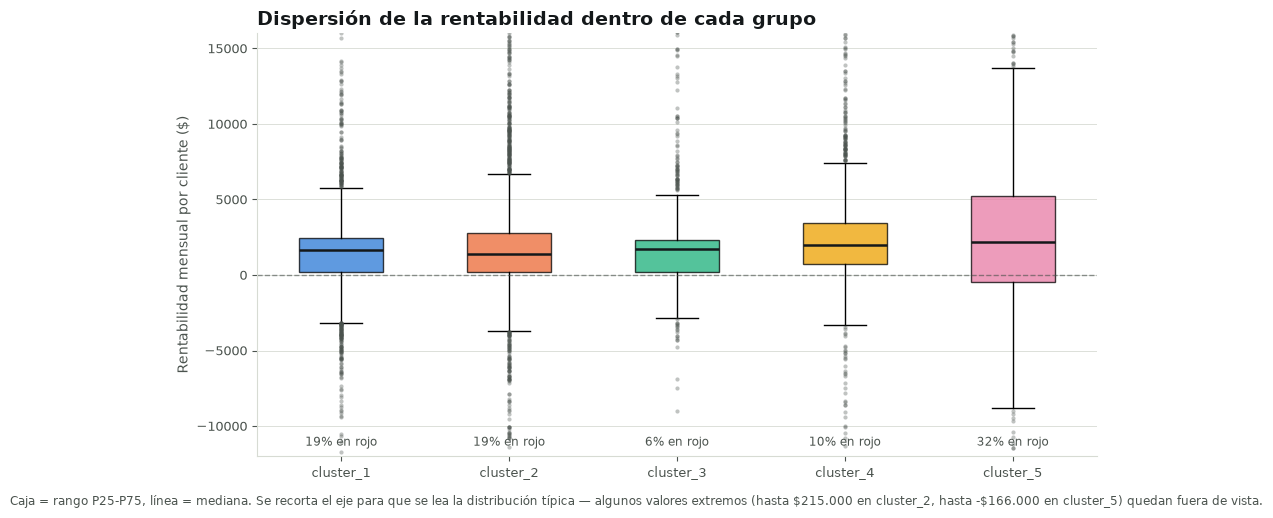

In [23]:
datos_caja = [df_churn.loc[df_churn[clu.CLUSTER_COL] == c, "mrentabilidad"] for c in range(1, 6)]
pct_negativos = [100 * (d < 0).mean() for d in datos_caja]

fig, ax = plt.subplots(figsize=(9.5, 5))
caja = ax.boxplot(datos_caja, tick_labels=[f"cluster_{c}" for c in range(1, 6)], patch_artist=True,
                   widths=0.5, showfliers=True, flierprops=dict(marker="o", markersize=3, alpha=0.35,
                   markerfacecolor=clu.INK_2, markeredgecolor="none"))
for patch, c in zip(caja["boxes"], range(1, 6)):
    patch.set_facecolor(clu.COLORES_CLUSTER[c - 1])
    patch.set_alpha(0.75)
for mediana in caja["medians"]:
    mediana.set_color(clu.INK)
    mediana.set_linewidth(1.8)

ax.axhline(0, color=clu.INK_2, linewidth=1, linestyle="--", alpha=0.6)
ax.set_ylim(-12000, 16000)
for i, pct in enumerate(pct_negativos, start=1):
    ax.text(i, -11500, f"{pct:.0f}% en rojo", ha="center", va="bottom", fontsize=8.5, color=clu.INK_2)

ax.set_ylabel("Rentabilidad mensual por cliente ($)", color=clu.INK_2)
ax.set_title("Dispersión de la rentabilidad dentro de cada grupo", fontsize=13.5, color=clu.INK, weight="bold", loc="left")
clu._estilo(ax)
plt.figtext(0.5, -0.02, "Caja = rango P25-P75, línea = mediana. Se recorta el eje para que se lea la distribución típica — algunos valores extremos (hasta \\$215.000 en cluster_2, hasta -\\$166.000 en cluster_5) quedan fuera de vista.",
            ha="center", fontsize=8.5, color=clu.INK_2)
plt.tight_layout()
plt.show()


**Tres cosas para marcar:**

1. **Cluster_3 ("Nunca Se Activó") es, por lejos, el más homogéneo** — la caja más angosta de las cinco, y sólo 6% de sus clientes con rentabilidad negativa. Tiene sentido: si un cliente casi no transacciona, tampoco genera sorpresas económicas para ningún lado. El promedio de este grupo es un número confiable.

2. **Cluster_4 ("Chico en Rojo") tiene el promedio más alto de los cinco, a pesar de ser el grupo con menos productos y saldo negativo.** La hipótesis más probable: un saldo en descubierto le cobra al cliente una tasa de interés alta, así que "estar en rojo" puede ser rentable para el banco en el corto plazo — aunque sea, a la vez, la señal más clara de un cliente financieramente frágil. El caso de negocio acá no es sólo "se pierde un cliente", es "se pierde un cliente que hoy paga intereses altos, y que probablemente los iba a dejar de pagar igual".

3. **Cluster_5 ("Sobre-endeudado") es, de lejos, el más disperso** — la caja más ancha y el 32% de sus clientes con rentabilidad ya negativa (el doble que cualquier otro grupo). El promedio ($2.319) esconde que son en realidad dos poblaciones: una parte que todavía paga intereses sobre su deuda, y casi un tercio que ya le cuesta plata al banco — compatible con lo que vimos antes sobre castigo de cartera. Es el argumento más fuerte para derivarlos a Riesgo y no tratarlos como una campaña comercial más.


In [24]:
for c in sorted(ARQUETIPOS):
    a = ARQUETIPOS[c]
    print(f"cluster_{c} · {a['nombre']}  ({tam[c]:,} clientes, {100*tam[c]/tam.sum():.1f}%)")
    print(f"  Variable clave : {a['variable_clave']}")
    print(f"  Motivo de baja : {a['motivo']}")
    print(f"  Acción         : {a['accion']}")
    print()


cluster_1 · El Tarjetahabiente Visa Desencantado  (1,281 clientes, 31.5%)
  Variable clave : Débitos automáticos en Visa
  Motivo de baja : Caen los pagos recurrentes y el consumo con la tarjeta antes de la baja: se van los clientes de más valor transaccional.
  Acción         : Oferta de beneficios/cashback o revisión de arancel a heavy-users con consumo Visa en caída, antes de que completen la fuga.

cluster_2 · El Sueldo que se Va  (1,089 clientes, 26.8%)
  Variable clave : Sueldo acreditado por nómina
  Motivo de baja : Caída abrupta del sueldo acreditado: compatible con migración de nómina a otro banco.
  Acción         : Alerta automática ante caída de nómina 2 meses seguidos; contacto de banca de relación con beneficios por domiciliar haberes.

cluster_3 · El Cliente Completo que Nunca Se Activó  (915 clientes, 22.5%)
  Variable clave : Actividad general (la más baja de los 5, pese a tener todos los productos)
  Motivo de baja : Tiene tarjeta y descubierto casi como un cliente f

## 5.1 ¿Quién se va cada mes?

Ya vimos (1.1) cuántos clientes se confirman como BAJA+2 cada mes. Ahora cruzamos ese dato con los 5 perfiles: de los que se van en marzo, ¿cuántos son de cada grupo? ¿Y en abril, mayo, junio? Esto muestra si la mezcla de perfiles es estable mes a mes o si algún perfil gana o pierde protagonismo con el tiempo.


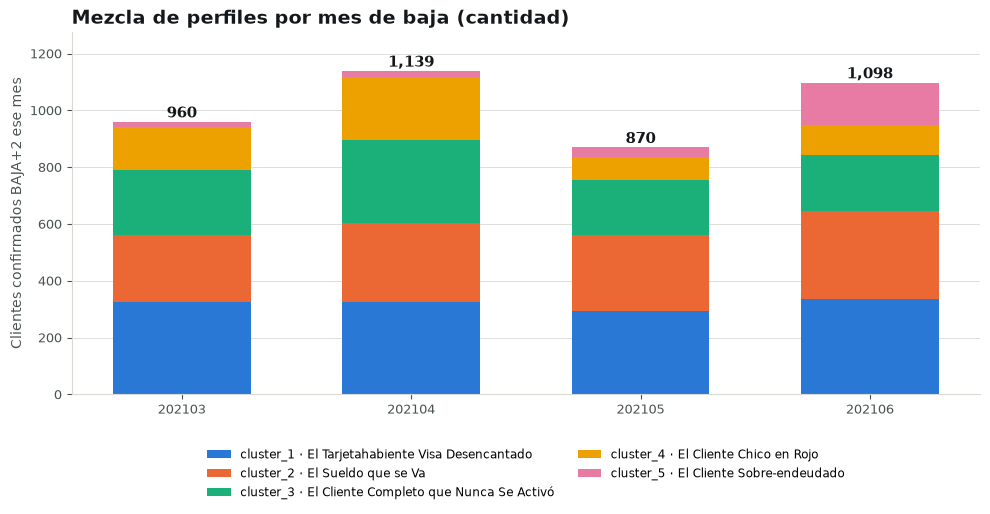

cluster     1    2    3    4    5
foto_mes                         
202103   33.9 24.5 23.9 15.9  1.9
202104   28.4 24.4 25.9 19.4  1.8
202105   33.9 30.7 22.3  9.2  3.9
202106   30.7 28.1 17.9  9.6 13.7


In [25]:
mes_de_baja = df.loc[(df[clu.GRUPO_COL] == 1) & (df[clu.TARGET_COL] == "BAJA+2"), [clu.ID_COL, clu.MES_COL]].set_index(clu.ID_COL)[clu.MES_COL]
mix_mensual = pd.crosstab(mes_de_baja, labels)

fig, ax = plt.subplots(figsize=(10, 5.3))
x = np.arange(len(mix_mensual.index))
abajo = np.zeros(len(mix_mensual.index))
for c in mix_mensual.columns:
    valores = mix_mensual[c].values
    ax.bar(x, valores, bottom=abajo, color=clu.COLORES_CLUSTER[c - 1], width=0.6,
            label=f"cluster_{c} · {ARQUETIPOS[c]['nombre']}")
    abajo += valores

for xi, t in zip(x, mix_mensual.sum(axis=1)):
    ax.text(xi, t + 15, f"{t:,}", ha="center", fontsize=10.5, color=clu.INK, weight="bold")

ax.set_xticks(x, mix_mensual.index)
ax.set_ylim(0, mix_mensual.sum(axis=1).max() * 1.12)
ax.set_ylabel("Clientes confirmados BAJA+2 ese mes", color=clu.INK_2)
ax.set_title("Mezcla de perfiles por mes de baja (cantidad)", fontsize=13.5, color=clu.INK, weight="bold", loc="left")
ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
clu._estilo(ax)
plt.tight_layout()
plt.show()

print((100 * mix_mensual.div(mix_mensual.sum(axis=1), axis=0)).round(1))


**Algo para marcar, con cuidado:** el Cliente Sobre-endeudado (cluster_5) se mantiene chico y estable en marzo-mayo (1,9% / 1,8% / 3,9% de las bajas de ese mes), pero en junio salta a **13,7%** (150 clientes) — casi 7 veces su participación habitual. Con sólo 223 clientes en todo el cluster, conviene desconfiar antes de afirmar que es un comportamiento real: 150 de esos 223 (67% del cluster entero) tiene su mes de baja en junio. Dos explicaciones compiten:

1. **Artefacto de detección:** cuantos más meses de historia tiene un cliente, más fácil es para el modelo reconocer con confianza un patrón tan extremo (lift 9,4). Los que se van en marzo sólo aportan 1-2 meses de evidencia; los de junio aportan hasta 5. Parte del salto puede ser "recién en junio el análisis lo ve bien", no "en junio se van más".
2. **Evento real de cartera:** algo le pasa a la deuda de este grupo específicamente en torno a junio-julio. Esto sí se puede chequear con los datos — ver la sección 5.2.


## 5.2 El Cliente Sobre-endeudado: ¿paga de a poco, o la deuda se corta de golpe?

Para elegir entre las dos explicaciones de arriba, miramos la trayectoria individual de `mprestamos_personales` y `cprestamos_personales` de los clientes del cluster_5, alineada no por mes calendario sino por **cercanía a su propio mes de baja** (offset 0 = el mes en que se confirma BAJA+2; offset -1 = el mes anterior; offset +1 = el único mes posterior que tenemos de ellos). Si la deuda cae de a poco a medida que se acercan a la baja, es compatible con un préstamo que simplemente termina de pagarse. Si se mantiene alta y estable y recién se corta después de la baja, es más compatible con una baja de cartera (castigo contable, reestructuración) que con un pago programado.


In [26]:
c5_hist = df_churn[df_churn[clu.CLUSTER_COL] == 5].copy()
c5_hist["mes_baja"] = c5_hist[clu.ID_COL].map(mes_de_baja)
c5_hist["offset"] = (c5_hist[clu.MES_COL] % 100) - (c5_hist["mes_baja"] % 100)

ids_cluster5 = c5_hist[clu.ID_COL].unique()
cohorte_junio = c5_hist.loc[c5_hist["mes_baja"] == 202106, clu.ID_COL].unique()
sub = c5_hist[c5_hist[clu.ID_COL].isin(cohorte_junio)]

piv_monto = sub.pivot_table(index=clu.ID_COL, columns="offset", values="mprestamos_personales")
piv_cant = sub.pivot_table(index=clu.ID_COL, columns="offset", values="cprestamos_personales")

print(f"Cohorte de junio (su mes de baja es 202106): {len(cohorte_junio):,} clientes, "
      f"el {100*len(cohorte_junio)/len(ids_cluster5):.0f}% del cluster_5 completo ({len(ids_cluster5):,}).")
print()
resumen_offset = pd.DataFrame({
    "mediana_deuda_$": piv_monto.median(),
    "mediana_cant_prestamos": piv_cant.median(),
}).round(0)
resumen_offset.index.name = "offset (0 = mes de la baja)"
resumen_offset


Cohorte de junio (su mes de baja es 202106): 150 clientes, el 67% del cluster_5 completo (223).

,mediana_deuda_$,mediana_cant_prestamos
offset (0 = mes de la baja),,
-3,"192,810.0",10.0
-2,"193,140.0",11.0
-1,"193,140.0",11.0
0,"179,604.0",11.0
1,"71,827.0",8.0


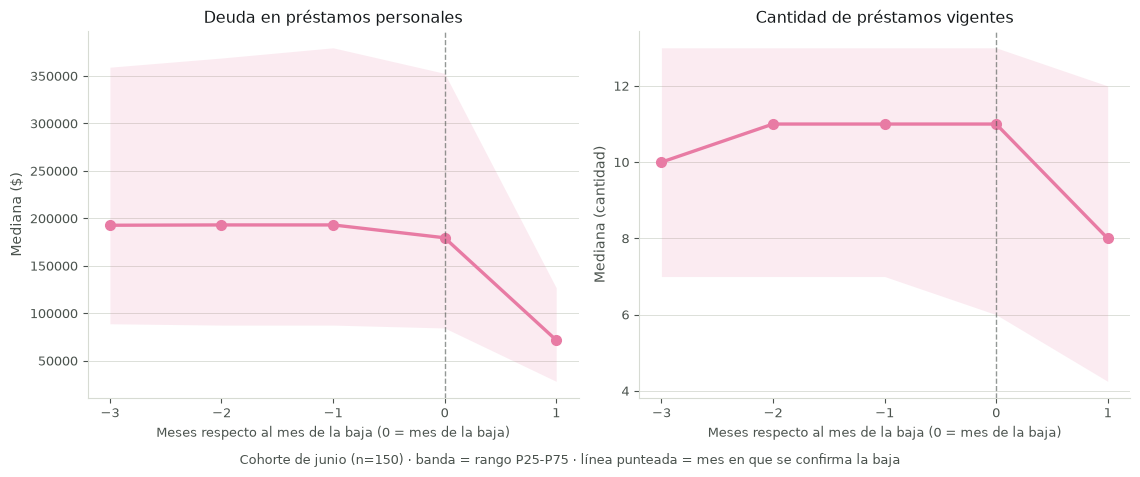

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
offsets = sorted(piv_monto.columns)
color = clu.COLORES_CLUSTER[4]  # mismo rosa/magenta usado para el cluster_5 en el resto del notebook

for ax, piv, titulo, ylabel in [
    (axes[0], piv_monto, "Deuda en préstamos personales", "Mediana ($)"),
    (axes[1], piv_cant, "Cantidad de préstamos vigentes", "Mediana (cantidad)"),
]:
    mediana = piv[offsets].median()
    p25 = piv[offsets].quantile(0.25)
    p75 = piv[offsets].quantile(0.75)
    ax.fill_between(offsets, p25, p75, color=color, alpha=0.15, linewidth=0)
    ax.plot(offsets, mediana, color=color, linewidth=2.4, marker="o", markersize=7)
    ax.axvline(0, color=clu.INK_2, linewidth=1, linestyle="--", alpha=0.6)
    ax.set_xticks(offsets)
    ax.set_xlabel("Meses respecto al mes de la baja (0 = mes de la baja)", color=clu.INK_2, fontsize=9)
    ax.set_ylabel(ylabel, color=clu.INK_2)
    ax.set_title(titulo, fontsize=11.5, color=clu.INK)
    clu._estilo(ax)

fig.text(0.5, -0.02, "Cohorte de junio (n=150) · banda = rango P25-P75 · línea punteada = mes en que se confirma la baja",
          ha="center", fontsize=9, color=clu.INK_2)
plt.tight_layout()
plt.show()


**Lectura:** la mediana de deuda está prácticamente plana entre offset -3 y offset 0 (de $192.810 a $179.604, apenas 7% de caída en cuatro meses) — no hay pendiente de pago gradual. El quiebre grande pasa recién en offset +1 (el único mes que vemos después de la baja): la deuda cae a la mitad y la cantidad de préstamos vigentes también baja (de 11 a 8 en la mediana) — no es sólo que se reduce el saldo, desaparecen préstamos enteros de la cuenta. Eso es más compatible con una baja de cartera o reestructuración que con "terminaron de pagar y se fueron contentos".

**Pero hay un límite real para la conclusión:** esta cohorte es la única con 150 clientes y un dato posterior a la baja; las cohortes de marzo/abril/mayo (18, 21 y 34 clientes) tienen su propio "mes siguiente" en abril/mayo/junio respectivamente, y ahí la caída es mucho más chica o inconsistente. Si fuera una regla general ("la deuda siempre se corta fuerte un mes después de cualquier baja"), debería verse también en esas cohortes tempranas — y no se ve con la misma fuerza. Eso hace sospechar que lo que estamos viendo puede ser específico de julio 2021 (un ciclo puntual de castigo de cartera, o cómo está construida la última foto disponible de este dataset) y no necesariamente "un mes después de cualquier baja, siempre pasa esto".

**Conclusión para el video:** el hallazgo sólido es *"estos clientes no bajan su deuda de a poco, se quedan estancados en deuda alta hasta el final"* — buen argumento para derivar a Riesgo. El salto de junio y el "por qué" del quiebre de julio quedan marcados como **a validar con la cátedra/documentación del dataset**, no como un hecho de negocio confirmado.


## Para el guion del video (sugerencia de orden)

1. **Abrir con la pregunta:** ¿se van todos por lo mismo? No.
2. **Cluster 1 y 2** primero — son los dos grupos más grandes (58% de las bajas juntos) y los de mayor rentabilidad mensual: el mensaje de mayor impacto económico.
3. **Cluster 3** — el "cliente que paga y no usa": fácil de entender, fácil de accionar con una campaña de activación.
4. **Cluster 4** — la señal de alerta temprana más clara del análisis (la app cae a la mitad antes de irse): un buen ejemplo de "pudimos haber actuado antes".
5. **Cerrar con el Cluster 5** — el más chico pero el más urgente: deuda, no desinterés. Buen cierre porque conecta Comercial con Riesgo.
